# Directional Wave Spectrum Estimation using Maximum Entropy Methods

This notebook demonstrates the estimation of directional wave spectra using Maximum Entropy Methods (MEM). 
We will explore two variants:
1. **MEM-I (Burg's Method)**: A closed-form solution that is computationally fast.
2. **MEM-II (Shannon's Method)**: An iterative approach maximizing Shannon entropy.

We will use a synthetic dataset based on a `sech2beta` spreading function to benchmark these methods.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, minimize
import warnings
warnings.filterwarnings('ignore')

In [5]:
def directional_mem_burg(theta, a1, b1, a2, b2):
    """
    Compute directional distribution using Burg's Maximum Entropy Method (MEM-I).
    Based on Lygre and Krogstad (1986).
    
    Parameters:
    -----------
    theta : array-like
        Angles in radians [0, 2π]
    a1, b1 : float
        First harmonic Fourier coefficients
    a2, b2 : float
        Second harmonic Fourier coefficients
        
    Returns:
    --------
    D : array
        Directional distribution values at theta (normalized)
    """
    theta = np.asarray(theta)
    
    # Complex Fourier coefficients
    c1 = a1 + 1j * b1
    c2 = a2 + 1j * b2
    
    # Check for validity (simple check)
    if np.abs(c1) >= 1:
        # Fallback or handle error
        return np.ones_like(theta) / (2*np.pi)

    # Solve Yule-Walker equations for phi1, phi2
    # phi2 = (c2 - c1^2) / (1 - |c1|^2)
    denom = 1 - np.abs(c1)**2
    if denom < 1e-6:
        phi2 = 0
        phi1 = c1
    else:
        phi2 = (c2 - c1**2) / denom
        phi1 = c1 - phi2 * np.conj(c1)
        
    # Error variance sigma^2
    # sigma^2 = 1 - phi1*c1* - phi2*c2*
    sigma2 = 1 - (phi1 * np.conj(c1) + phi2 * np.conj(c2)).real
    
    # Compute denominator |1 - phi1*e^(-it) - phi2*e^(-2it)|^2
    e_it = np.exp(-1j * theta)
    e_2it = np.exp(-2j * theta)
    
    poly = 1 - phi1 * e_it - phi2 * e_2it
    denom_poly = np.abs(poly)**2
    
    # D(theta)
    D = sigma2 / (2 * np.pi * denom_poly)
    
    return D


In [ ]:
def directional_mem_shannon(theta, a1, b1, a2, b2):
    """
    Compute directional distribution using Shannon's Maximum Entropy Method (MEM-II).
    
    The MEM solution has the form:
    D(θ) = exp(λ1*cos(θ) + λ2*sin(θ) + λ3*cos(2θ) + λ4*sin(2θ)) / Z
    
    Parameters:
    -----------
    theta : array-like
        Angles in radians [0, 2π]
    a1, b1 : float
        First harmonic Fourier coefficients
    a2, b2 : float
        Second harmonic Fourier coefficients
    
    Returns:
    --------
    D : array
        Directional distribution values at theta (normalized)
    """
    theta_array = np.asarray(theta)
    
    # Define the constraint equations
    def constraints(lambdas):
        l1, l2, l3, l4 = lambdas
        
        # Integration points
        theta_int = np.linspace(0, 2*np.pi, 360)
        
        # Unnormalized distribution
        exp_arg = (l1*np.cos(theta_int) + l2*np.sin(theta_int) + 
                   l3*np.cos(2*theta_int) + l4*np.sin(2*theta_int))
        
        # Avoid overflow
        exp_arg = exp_arg - np.max(exp_arg)
        D_unnorm = np.exp(exp_arg)
        
        # Normalization constant
        Z = np.trapz(D_unnorm, theta_int)
        
        # Normalized distribution
        D_norm = D_unnorm / Z
        
        # Compute Fourier coefficients
        a1_est = np.trapz(D_norm * np.cos(theta_int), theta_int)
        b1_est = np.trapz(D_norm * np.sin(theta_int), theta_int)
        a2_est = np.trapz(D_norm * np.cos(2*theta_int), theta_int)
        b2_est = np.trapz(D_norm * np.sin(2*theta_int), theta_int)
        
        return [a1_est - a1, b1_est - b1, a2_est - a2, b2_est - b2]
    
    # Initial guess
    lambda0 = [2*a1, 2*b1, 2*a2, 2*b2]
    
    try:
        lambdas_opt = fsolve(constraints, lambda0)
        l1, l2, l3, l4 = lambdas_opt
    except:
        # Fallback to minimization
        def objective(lambdas):
            return np.sum(np.array(constraints(lambdas))**2)
        res = minimize(objective, lambda0, method='Nelder-Mead')
        l1, l2, l3, l4 = res.x
    
    # Compute D(θ) at requested angles
    exp_arg = (l1*np.cos(theta_array) + l2*np.sin(theta_array) + 
               l3*np.cos(2*theta_array) + l4*np.sin(2*theta_array))
    exp_arg = exp_arg - np.max(exp_arg) # Stability
    D_unnorm = np.exp(exp_arg)
    
    # Normalize
    theta_int = np.linspace(0, 2*np.pi, 360)
    exp_arg_int = (l1*np.cos(theta_int) + l2*np.sin(theta_int) + 
                   l3*np.cos(2*theta_int) + l4*np.sin(2*theta_int))
    exp_arg_int = exp_arg_int - np.max(exp_arg_int)
    Z = np.trapz(np.exp(exp_arg_int), theta_int)
    
    return D_unnorm / Z


## Synthetic Example: Donelan et al. (1985) Distribution

We will generate a synthetic directional distribution using the model proposed by Donelan et al. (1985):
$$ D(\theta) = \frac{1}{2}\beta \text{sech}^{2}(\beta(\theta - \theta_m)) $$


In [6]:
def sech2beta(theta, theta_m, beta):
    """
    Compute directional distribution using Donelan et al. (1985) model.
    D(theta) = 0.5 * beta * sech^2(beta * (theta - theta_m))
    """
    # Center theta around theta_m for calculation
    # Handle wrapping
    dtheta = theta - theta_m
    dtheta = (dtheta + np.pi) % (2*np.pi) - np.pi
    
    # sech(x) = 1/cosh(x)
    # D(theta) ~ sech^2(beta * dtheta)
    val = 1.0 / (np.cosh(beta * dtheta)**2)
    
    # Normalize
    # Numerical integration for normalization to ensure integral is 1 over [0, 2pi]
    A = np.trapz(val, theta)
    return val / A


## Comparison of MEM-I and MEM-II

Now we reconstruct the distribution using the computed Fourier coefficients.


## Library of Test Conditions



In [7]:
class CasesGenerator:
    def __init__(self, theta_deg):
        self.theta_deg = theta_deg
        self.theta_rad = np.deg2rad(theta_deg)
        
    def sech2beta(self, theta_m_deg, beta):
        theta_m = np.deg2rad(theta_m_deg)
        return sech2beta(self.theta_rad, theta_m, beta)
        
    def unimodal(self, theta_m=180, beta=4):
        return self.sech2beta(theta_m, beta)
        
    def bimodal(self, theta_m1=150, beta1=10, theta_m2=210, beta2=10, ratio=0.5):
        D1 = self.sech2beta(theta_m1, beta1)
        D2 = self.sech2beta(theta_m2, beta2)
        # Combine with energy ratio (ratio is fraction of total energy in peak 1)
        # Since D1 and D2 are normalized to area 1:
        D = ratio * D1 + (1 - ratio) * D2
        return D

# Initialize library
theta = np.linspace(-180, 180, 1000)
lib = CasesGenerator(theta)
cases = {}
cases['Unimodal Narrow'] = lib.unimodal(theta_m=0, beta=20)
cases['Unimodal Broad'] = lib.unimodal(theta_m=0, beta=2)
cases['Bimodal Far (Equal)'] = lib.bimodal(theta_m1=-45, beta1=12, theta_m2=45, beta2=12, ratio=0.5)
cases['Bimodal Close (Equal)'] = lib.bimodal(theta_m1=-10, beta1=15, theta_m2=10, beta2=15, ratio=0.5)
cases['Bimodal Far (Unequal)'] = lib.bimodal(theta_m1=-45, beta1=12, theta_m2=45, beta2=6, ratio=0.7)
cases['Bimodal Close (Unequal)'] = lib.bimodal(theta_m1=-10, beta1=12, theta_m2=10, beta2=6, ratio=0.4)

# Function to process a single case
def process_case(name, D_true, theta_rad):
    # Compute Fourier Coefficients
    a1 = np.trapz(D_true * np.cos(theta_rad), theta_rad)
    b1 = np.trapz(D_true * np.sin(theta_rad), theta_rad)
    a2 = np.trapz(D_true * np.cos(2*theta_rad), theta_rad)
    b2 = np.trapz(D_true * np.sin(2*theta_rad), theta_rad)
    
    # Reconstruct
    D_burg = directional_mem_burg(theta_rad, a1, b1, a2, b2)
    D_shannon = directional_mem_shannon(theta_rad, a1, b1, a2, b2)
    
    return D_burg, D_shannon

# Run all cases
results = {}
for name, D_true in cases.items():
    results[name] = process_case(name, D_true, lib.theta_rad)


In [8]:
def calculate_rmse(D_true, D_est):
    """Root Mean Square Error"""
    return np.sqrt(np.mean((D_true - D_est)**2))

def calculate_kl_divergence(D_true, D_est, epsilon=1e-10):
    """Kullback-Leibler Divergence: D_KL(True || Est)"""
    # Add epsilon to avoid log(0) or division by zero
    P = D_true + epsilon
    Q = D_est + epsilon
    
    # Normalize again to ensure they sum to 1 (conceptually, though we work with densities)
    # For KL, we treat them as probability distributions
    P = P / np.sum(P)
    Q = Q / np.sum(Q)
    
    return np.sum(P * np.log(P / Q))

Unimodal Narrow  KL Burg:  1.5293896278654129
Unimodal Narrow  KL Shannon:  0.013939333411351444
Unimodal Broad  KL Burg:  0.1474619315816293
Unimodal Broad  KL Shannon:  0.0016853660574880473
Bimodal Far (Equal)  KL Burg:  1.0894956448905062
Bimodal Far (Equal)  KL Shannon:  0.01855518145760443
Bimodal Close (Equal)  KL Burg:  1.2836077164728272
Bimodal Close (Equal)  KL Shannon:  0.09391810571428519
Bimodal Far (Unequal)  KL Burg:  0.8239210964840826
Bimodal Far (Unequal)  KL Shannon:  0.1206499363270633
Bimodal Close (Unequal)  KL Burg:  0.8343190098915954
Bimodal Close (Unequal)  KL Shannon:  0.07405390422399628


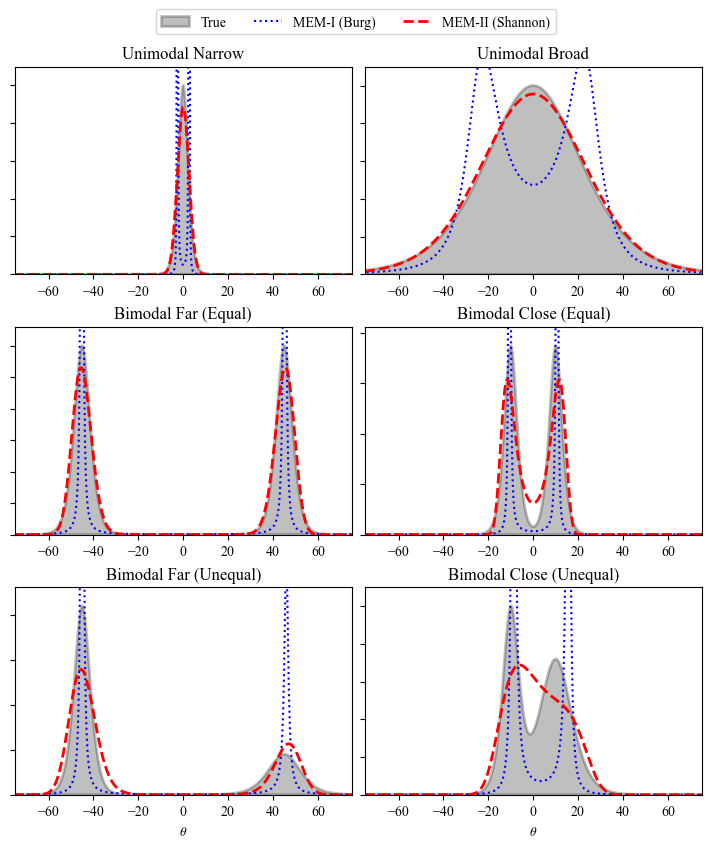

In [13]:
# Plotting the Library Results
fig, axes = plt.subplots(3, 2, figsize=(7, 8), layout="constrained")
axes = axes.flatten()

for i, (name, D_true) in enumerate(cases.items()):
    ax = axes[i]
    D_burg, D_shannon = results[name]
    
    # Polar plot expects radians
    ax.fill_between(lib.theta_deg, D_true, color="k", linewidth=2, label='True', alpha=0.25)
    ax.plot(lib.theta_deg, D_burg, 'b:', linewidth=1.5, label='MEM-I (Burg)')
    ax.plot(lib.theta_deg, D_shannon, 'r--', linewidth=2, label='MEM-II (Shannon)')
    
    ax.set_title(name)
    ax.set_xlim((-75, 75))
    ax.set_ylim((0, 1.1 * D_true.max()))
    ax.set_yticklabels([])

    kl_burg = calculate_kl_divergence(D_true, D_burg)
    kl_shannon = calculate_kl_divergence(D_true, D_shannon)
    print(name, " KL Burg: ", kl_burg)
    print(name, " KL Shannon: ", kl_shannon)
    
    # Only show legend on first plot
    if i == 0:
        fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncols=3)
    if i >= 4:
        ax.set_xlabel("$\\theta$")

plt.show()

fig.savefig('../images/mem-comparison-six-panel.png', dpi=300)

In [15]:
# Metric functions
def calculate_rmse(D_true, D_est):
    """Root Mean Square Error"""
    return np.sqrt(np.mean((D_true - D_est)**2))

def calculate_kl_divergence(D_true, D_est, epsilon=1e-10):
    """Kullback-Leibler Divergence: D_KL(True || Est)"""
    P = D_true + epsilon
    Q = D_est + epsilon
    P = P / np.sum(P)
    Q = Q / np.sum(Q)
    return np.sum(P * np.log(P / Q))

def calculate_fourier_error(D_true, D_est, theta_rad):
    """
    Euclidean distance between Fourier coefficients
    sqrt((a1_t - a1_e)^2 + (b1_t - b1_e)^2 + (a2_t - a2_e)^2 + (b2_t - b2_e)^2)
    """
    # True coefficients
    a1_true = np.trapz(D_true * np.cos(theta_rad), theta_rad)
    b1_true = np.trapz(D_true * np.sin(theta_rad), theta_rad)
    a2_true = np.trapz(D_true * np.cos(2*theta_rad), theta_rad)
    b2_true = np.trapz(D_true * np.sin(2*theta_rad), theta_rad)
    
    # Estimated coefficients
    a1_est = np.trapz(D_est * np.cos(theta_rad), theta_rad)
    b1_est = np.trapz(D_est * np.sin(theta_rad), theta_rad)
    a2_est = np.trapz(D_est * np.cos(2*theta_rad), theta_rad)
    b2_est = np.trapz(D_est * np.sin(2*theta_rad), theta_rad)
    
    # Euclidean distance
    error = np.sqrt(
        (a1_true - a1_est)**2 + 
        (b1_true - b1_est)**2 + 
        (a2_true - a2_est)**2 + 
        (b2_true - b2_est)**2
    )
    return error

# Generate random test cases
def generate_random_cases(n_cases=50):
    """Generate n random directional distributions"""
    theta = np.linspace(-180, 180, 1000)
    theta_rad = np.deg2rad(theta)
    lib = CasesGenerator(theta)
    
    cases = []
    for i in range(n_cases):
        if np.random.rand() > 0.5:
            # Unimodal
            theta_m = np.random.uniform(-180, 180)
            beta = np.random.uniform(2, 30)
            D = lib.unimodal(theta_m=theta_m, beta=beta)
        else:
            # Bimodal
            theta_m1 = np.random.uniform(-180, 180)
            theta_m2 = np.random.uniform(-180, 180)
            beta1 = np.random.uniform(5, 25)
            beta2 = np.random.uniform(5, 25)
            ratio = np.random.uniform(0.3, 0.7)
            D = lib.bimodal(theta_m1=theta_m1, beta1=beta1, 
                           theta_m2=theta_m2, beta2=beta2, ratio=ratio)
        cases.append(D)
    
    return cases, theta_rad

# Process cases and compute metrics
def analyze_random_cases(n_cases=100):
    """Generate random cases and compute metrics"""
    cases, theta_rad = generate_random_cases(n_cases)
    
    rmse_burg = []
    rmse_shannon = []
    kl_burg = []
    kl_shannon = []
    fourier_burg = []
    fourier_shannon = []
    
    for D_true in cases:
        # Compute Fourier Coefficients
        a1 = np.trapz(D_true * np.cos(theta_rad), theta_rad)
        b1 = np.trapz(D_true * np.sin(theta_rad), theta_rad)
        a2 = np.trapz(D_true * np.cos(2*theta_rad), theta_rad)
        b2 = np.trapz(D_true * np.sin(2*theta_rad), theta_rad)
        
        # Reconstruct
        D_burg = directional_mem_burg(theta_rad, a1, b1, a2, b2)
        D_shannon = directional_mem_shannon(theta_rad, a1, b1, a2, b2)
        
        # Calculate metrics
        rmse_burg.append(calculate_rmse(D_true, D_burg))
        rmse_shannon.append(calculate_rmse(D_true, D_shannon))
        kl_burg.append(calculate_kl_divergence(D_true, D_burg))
        kl_shannon.append(calculate_kl_divergence(D_true, D_shannon))
        fourier_burg.append(calculate_fourier_error(D_true, D_burg, theta_rad))
        fourier_shannon.append(calculate_fourier_error(D_true, D_shannon, theta_rad))
    
    return {
        'rmse_burg': np.array(rmse_burg),
        'rmse_shannon': np.array(rmse_shannon),
        'kl_burg': np.array(kl_burg),
        'kl_shannon': np.array(kl_shannon),
        'fourier_burg': np.array(fourier_burg),
        'fourier_shannon': np.array(fourier_shannon)
    }

# Run analysis and plot results
results = analyze_random_cases(n_cases=100)
results

{'rmse_burg': array([1.59052307, 1.27402214, 2.54305633, 1.36356293, 0.57623261,
        4.77253112, 2.20077346, 1.18905027, 1.44064089, 1.1056435 ,
        1.86328592, 1.57393951, 1.5115334 , 2.49466368, 1.52867721,
        0.89633964, 7.68989096, 1.45479616, 2.6281437 , 0.82946978,
        3.95224847, 5.65925147, 2.20196885, 1.03128184, 1.67947581,
        2.05817298, 4.34905946, 3.75567558, 1.87560973, 2.08379454,
        1.88033094, 2.18799045, 2.14203207, 0.84064758, 1.40367092,
        1.82178613, 2.85679059, 2.00237887, 1.82905865, 2.0752041 ,
        0.35422157, 1.85948041, 1.53948391, 1.59267639, 0.75766673,
        1.83372478, 1.44774788, 1.64352837, 1.2003874 , 1.6107206 ,
        2.72520457, 1.83545583, 0.6966469 , 1.62265258, 0.80606893,
        1.53554496, 0.87973658, 1.15948353, 1.34824126, 1.86572994,
        1.46549146, 0.74650491, 0.65641878, 0.58051739, 1.53226885,
        1.5725896 , 0.74599178, 1.08538302, 1.3675917 , 1.8728662 ,
        1.59915632, 3.03683239, 1.6

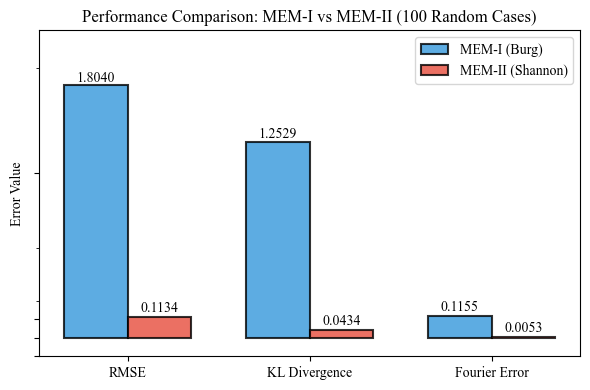

In [16]:
# Create grouped bar plot
fig, ax = plt.subplots(figsize=(6, 4))

x_pos = np.arange(3)
width = 0.35
metric_labels = ['RMSE', 'KL Divergence', 'Fourier Error']

# MEM-I (Burg) bars
metrics_burg = [
    results['rmse_burg'].mean(),
    results['kl_burg'].mean(),
    results['fourier_burg'].mean()
]

# MEM-II (Shannon) bars
metrics_shannon = [
    results['rmse_shannon'].mean(),
    results['kl_shannon'].mean(),
    results['fourier_shannon'].mean()
]

# Plot bars
bars1 = ax.bar(x_pos - width/2, metrics_burg, width, 
               label='MEM-I (Burg)', color='#3498db', 
               alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x_pos + width/2, metrics_shannon, width,
               label='MEM-II (Shannon)', color='#e74c3c', 
               alpha=0.8, edgecolor='black', linewidth=1.5)

# Add values on top of bars
for i, (bar, val) in enumerate(zip(bars1, metrics_burg)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.4f}', ha='center', va='bottom')

for i, (bar, val) in enumerate(zip(bars2, metrics_shannon)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.4f}', ha='center', va='bottom')

ax.set_ylabel('Error Value')
ax.set_title('Performance Comparison: MEM-I vs MEM-II (100 Random Cases)')
ax.set_xticks(x_pos)
ax.set_xticklabels(metric_labels)
ax.legend(loc='upper right')

ax.set_ylim((-0.1, 2.5))
ax.set_yscale("asinh")
ax.set_yticklabels([])

plt.tight_layout()
plt.show()

fig.savefig('../images/mem-performance-metrics.png', dpi=300)

In [17]:
# Print summary statistics
print("="*70)
print("SUMMARY STATISTICS (100 Random Cases)")
print("="*70)
print(f"\nRMSE:")
print(f"  MEM-I (Burg):      {results['rmse_burg'].mean():.6f} ± {results['rmse_burg'].std():.6f}")
print(f"  MEM-II (Shannon):  {results['rmse_shannon'].mean():.6f} ± {results['rmse_shannon'].std():.6f}")
print(f"\nKL Divergence:")
print(f"  MEM-I (Burg):      {results['kl_burg'].mean():.6f} ± {results['kl_burg'].std():.6f}")
print(f"  MEM-II (Shannon):  {results['kl_shannon'].mean():.6f} ± {results['kl_shannon'].std():.6f}")
print(f"\nFourier Coefficient Error:")
print(f"  MEM-I (Burg):      {results['fourier_burg'].mean():.6f} ± {results['fourier_burg'].std():.6f}")
print(f"  MEM-II (Shannon):  {results['fourier_shannon'].mean():.6f} ± {results['fourier_shannon'].std():.6f}")
print("="*70)

SUMMARY STATISTICS (100 Random Cases)

RMSE:
  MEM-I (Burg):      1.898054 ± 0.983176
  MEM-II (Shannon):  0.123625 ± 0.066699

KL Divergence:
  MEM-I (Burg):      1.317032 ± 0.429029
  MEM-II (Shannon):  0.051289 ± 0.072218

Fourier Coefficient Error:
  MEM-I (Burg):      0.119226 ± 0.169979
  MEM-II (Shannon):  0.004959 ± 0.006821
